In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
from DataSet import *
from Configs import emotion_mapping, PATH
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.cm as cm

In [ ]:
print("Path to dataset files:", PATH)


Path to dataset files: /Users/julietaggarciapereyra/.cache/kagglehub/datasets/msambare/fer2013/versions/1


In [3]:
train_dataset, train_labels = load_data(os.path.join(PATH, "train"), emotion_mapping)
test_dataset, test_labels = load_data(os.path.join(PATH, "test"), emotion_mapping)

print(f"Datos de entrenamiento: {train_dataset.shape}, {train_labels.shape}")
print(f"Datos de prueba: {test_dataset.shape}, {test_labels.shape}")

Datos de entrenamiento: (28709, 48, 48), (28709,)
Datos de prueba: (7178, 48, 48), (7178,)


In [4]:
X_train, X_test, Y_train, Y_test = get_X_Y_arrays(PATH, emotion_mapping, channels=3)
X_train_pil = [Image.fromarray(img.astype('uint8')) for img in X_train]
X_test_pil = [Image.fromarray(img.astype('uint8')) for img in X_test]

In [5]:
preprocess = image_preprocess_transforms()
training_dataset, testing_dataset = create_datasets(X_train_pil, Y_train, X_test_pil, Y_test, preprocess)
train_data, valid_data, train_indices, valid_indices = split_train_valid(training_dataset, train_labels, valid_split=0.2)

print(f"Tamaño de train: {len(train_data)}")
print(f"Tamaño de valid: {len(valid_data)}")

Tamaño de train: 22967
Tamaño de valid: 5742


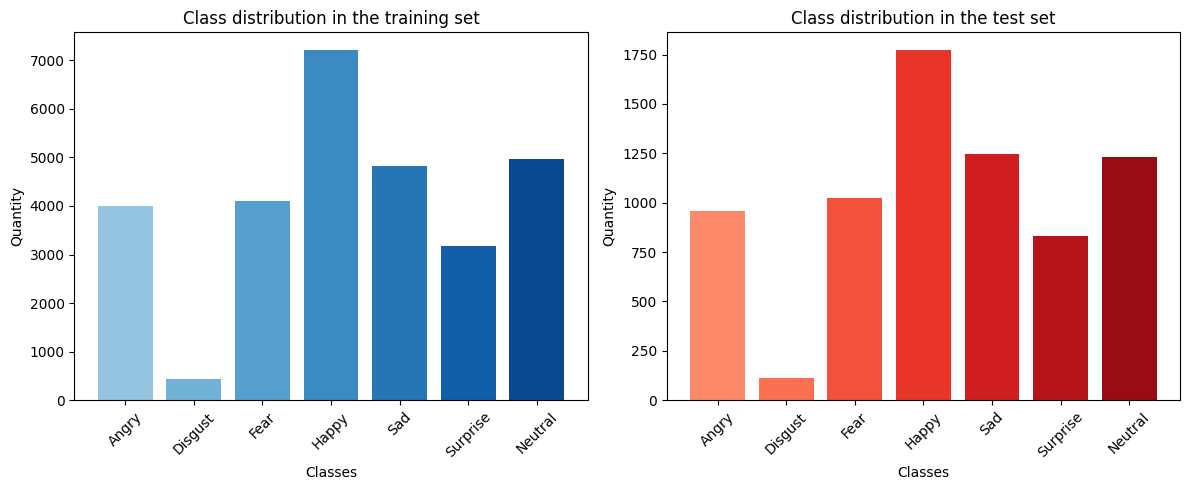

In [6]:
train_class_counts = Counter(train_labels)
test_class_counts = Counter(test_labels)

emotion_names = {v: k for k, v in emotion_mapping.items()}

train_class_counts_sorted = [train_class_counts[i] for i in range(len(emotion_mapping))]
test_class_counts_sorted = [test_class_counts[i] for i in range(len(emotion_mapping))]
emotion_labels_sorted = [emotion_names[i] for i in range(len(emotion_mapping))]

train_colors = cm.Blues(np.linspace(0.4, 0.9, len(emotion_mapping)))
test_colors = cm.Reds(np.linspace(0.4, 0.9, len(emotion_mapping)))

plt.figure(figsize=(12, 5))

# Gráfico del conjunto de entrenamiento
plt.subplot(1, 2, 1)
plt.bar(emotion_labels_sorted, train_class_counts_sorted, color=train_colors)
plt.title('Class distribution in the training set')
plt.xlabel('Classes')
plt.ylabel('Quantity')
plt.xticks(rotation=45)

# Gráfico del conjunto de prueba
plt.subplot(1, 2, 2)
plt.bar(emotion_labels_sorted, test_class_counts_sorted, color=test_colors)
plt.title('Class distribution in the test set')
plt.xlabel('Classes')
plt.ylabel('Quantity')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()
